# H3 — Compounding vulnerability: connectivity gaps and service gaps overlap

**Claim under test.** Communities beyond the mobile-coverage gap threshold are not randomly
worse-served on other dimensions — they are systematically further from schools, medical
facilities and emergency services, and disproportionately likely to have none of the three
nearby at all.

- **H0 (null):** distance to the nearest school / medical facility / emergency service is
  independent of mobile connectivity-gap status (`distance_gap_candidate`) — the two groups'
  distance distributions are the same, and having zero services within 10 km is no more common
  in one group than the other.
- **H1 (alternative):** communities beyond the mobile-gap threshold have significantly greater
  distances to every service type, and a significantly higher rate of zero services within
  10 km.

**Data:** `village_gap_with_services.csv` (carries both the connectivity-gap flag from
`notebooks/06` and the service distances from `notebooks/11` in one table already).

**Method.** Service distances are right-skewed (a long tail of very remote communities), so a
rank-based test is appropriate rather than a t-test: two-sided **Mann-Whitney U** per service
type, with rank-biserial correlation as effect size. For the "zero services nearby" question,
a 2x2 **Fisher's exact test** (gap status) x (zero services within 10 km), with odds ratio.

In [1]:
# Every import for the whole notebook lives in this cell.
%matplotlib inline
import os
from pathlib import Path

if os.path.basename(os.getcwd()) == "hypothesis_proof_notebooks":
    os.chdir("..")

import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 220)
DATA = Path("data/processed")


In [2]:
vg = pd.read_csv(DATA / "village_gap_with_services.csv", dtype={"sa1_code": str})
assert vg["community_id"].is_unique and len(vg) == 792

gap = vg[vg["distance_gap_candidate"] == True]
notgap = vg[vg["distance_gap_candidate"] == False]
print(f"beyond mobile-gap threshold: {len(gap)}")
print(f"within mobile-gap threshold: {len(notgap)}")

SERVICES = [("km_nearest_school", "school"), ("km_nearest_medical", "medical"), ("km_nearest_emergency", "emergency")]
desc = pd.DataFrame({
    label: {
        "gap median (km)": gap[col].median(), "gap IQR": gap[col].quantile(.75) - gap[col].quantile(.25),
        "non-gap median (km)": notgap[col].median(), "non-gap IQR": notgap[col].quantile(.75) - notgap[col].quantile(.25),
    } for col, label in SERVICES
}).T
desc.round(1)

beyond mobile-gap threshold: 384
within mobile-gap threshold: 408


,gap median (km),gap IQR,non-gap median (km),non-gap IQR
school,39.2,37.4,7.4,16.2
medical,46.2,43.5,10.2,29.2
emergency,47.7,45.9,12.2,30.6


## Mann-Whitney U tests: is the gap group's distance distribution shifted higher?

In [3]:
results = {}
for col, label in SERVICES:
    a, b = gap[col].dropna(), notgap[col].dropna()
    u, p = stats.mannwhitneyu(a, b, alternative="greater")   # H1: gap-group distances > non-gap-group distances
    n1, n2 = len(a), len(b)
    rank_biserial = 1 - (2 * u) / (n1 * n2)     # effect size: -1..1, 0 = no difference
    results[label] = (u, p, rank_biserial)
    print(f"{label:10s}  gap median={a.median():6.1f} km   non-gap median={b.median():6.1f} km   "
          f"U={u:,.0f}   p={p:.3e}   rank-biserial r={rank_biserial:.3f}")
print()
print("rank-biserial r close to 1 = almost every gap-group distance exceeds almost every",
      "non-gap-group distance (a very large, not marginal, effect).")

school      gap median=  39.2 km   non-gap median=   7.4 km   U=133,772   p=7.945e-67   rank-biserial r=-0.708
medical     gap median=  46.2 km   non-gap median=  10.2 km   U=129,754   p=8.823e-58   rank-biserial r=-0.656
emergency   gap median=  47.7 km   non-gap median=  12.2 km   U=128,618   p=2.390e-55   rank-biserial r=-0.642

rank-biserial r close to 1 = almost every gap-group distance exceeds almost every non-gap-group distance (a very large, not marginal, effect).


## Fisher's exact test: zero services within 10 km

`n_schools_10km`, `n_medical_10km`, `n_emergency_10km` are already computed by
`notebooks/11_services_gap.ipynb`. A community has "zero services nearby" if all three are 0.

In [4]:
vg["zero_services_10km"] = (
    (vg["n_schools_10km"] == 0) & (vg["n_medical_10km"] == 0) & (vg["n_emergency_10km"] == 0)
)
ct = pd.crosstab(vg["distance_gap_candidate"], vg["zero_services_10km"])
ct.index = ["within mobile-gap threshold", "beyond mobile-gap threshold"]
ct.columns = ["has >=1 service within 10km", "zero services within 10km"]
print(ct)

odds_ratio, p_fisher = stats.fisher_exact(ct)
rate_gap = vg.loc[vg["distance_gap_candidate"], "zero_services_10km"].mean()
rate_notgap = vg.loc[~vg["distance_gap_candidate"], "zero_services_10km"].mean()
print()
print(f"rate of 'zero services within 10km': {rate_gap:.1%} (beyond gap) vs {rate_notgap:.1%} (within gap)")
print(f"Fisher's exact test: odds ratio={odds_ratio:.1f}   p={p_fisher:.3e}")

                             has >=1 service within 10km  zero services within 10km
within mobile-gap threshold                          250                        158
beyond mobile-gap threshold                            9                        375

rate of 'zero services within 10km': 97.7% (beyond gap) vs 38.7% (within gap)
Fisher's exact test: odds ratio=65.9   p=4.930e-82


## Visualisation

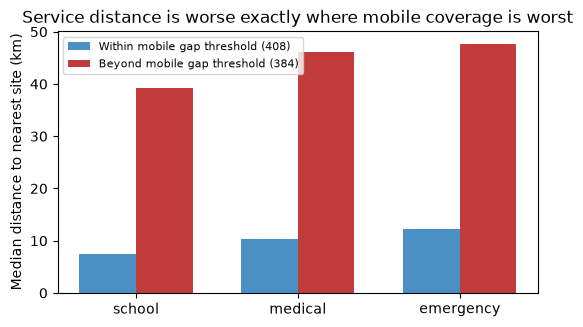

In [5]:
labels = [l for _, l in SERVICES]
gap_med = [gap[c].median() for c, _ in SERVICES]
notgap_med = [notgap[c].median() for c, _ in SERVICES]
x = np.arange(len(labels)); w = 0.35

fig, ax = plt.subplots(figsize=(6.2, 3.4))
ax.bar(x - w/2, notgap_med, w, label=f"Within mobile gap threshold ({len(notgap)})", color="#4A90C4")
ax.bar(x + w/2, gap_med, w, label=f"Beyond mobile gap threshold ({len(gap)})", color="#C23B3B")
ax.set_xticks(x, labels)
ax.set_ylabel("Median distance to nearest site (km)")
ax.set_title("Service distance is worse exactly where mobile coverage is worst")
ax.legend(fontsize=8)
plt.show()

## Conclusion

In [6]:
print("H3 SUMMARY")
print("=" * 60)
for col, label in SERVICES:
    u, p, r = results[label]
    print(f"- {label}: Mann-Whitney p={p:.2e}, rank-biserial r={r:.2f}  "
          f"({'REJECT H0' if p < 0.05 else 'fail to reject H0'})")
print(f"- zero-services-within-10km rate: {rate_gap:.0%} (beyond gap) vs {rate_notgap:.0%} (within gap)")
print(f"  Fisher's exact test: OR={odds_ratio:.1f}, p={p_fisher:.2e}  "
      f"({'REJECT H0' if p_fisher < 0.05 else 'fail to reject H0'})")
print()
print("=> H3 is SUPPORTED: a mobile-coverage gap in the NT is very rarely an isolated problem --")
print("   it is strongly, statistically associated with being far from every other essential")
print("   service measured here, not an independent risk.")

H3 SUMMARY
- school: Mann-Whitney p=7.95e-67, rank-biserial r=-0.71  (REJECT H0)
- medical: Mann-Whitney p=8.82e-58, rank-biserial r=-0.66  (REJECT H0)
- emergency: Mann-Whitney p=2.39e-55, rank-biserial r=-0.64  (REJECT H0)
- zero-services-within-10km rate: 98% (beyond gap) vs 39% (within gap)
  Fisher's exact test: OR=65.9, p=4.93e-82  (REJECT H0)

=> H3 is SUPPORTED: a mobile-coverage gap in the NT is very rarely an isolated problem --
   it is strongly, statistically associated with being far from every other essential
   service measured here, not an independent risk.


**Ethical note.** This is a strong reason to treat connectivity investment and
service-delivery planning as linked, not siloed decisions — see the Recommendations section of
the project report. It is **not** a reason to fold the two into one silent score inside the
pipeline: which matters more, and how to weight them, is a policy judgement for government and
community stakeholders, made deliberately in the open rather than baked into the data.